# analysis extended

this notebook compares original and reconstructed audio (both internal and external samples): audio players, waveforms, and log-mel spectrograms

In [1]:
from pathlib import Path
import os, urllib.parse, requests

REPO_URL = "https://github.com/akhasanovv/soundstream-implementation.git"
REPO_DIR = Path("/soundstream-implementation")

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
os.chdir(REPO_DIR)

Cloning into '/soundstream-implementation'...
remote: Enumerating objects: 230, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 230 (delta 100), reused 181 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (230/230), 591.96 KiB | 6.23 MiB/s, done.
Resolving deltas: 100% (100/100), done.


In [ ]:
!pip install -r requirements.txt

In [2]:
import matplotlib.pyplot as plt
import torch
import torchaudio
from IPython.display import Audio, Markdown, display

from src.model import SoundStreamModel

SAMPLE_RATE = 16000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_URL = "https://huggingface.co/akhasanovv/soundstream-implementation/resolve/main/model_best.pth"
CKPT_PATH = REPO_DIR / "saved" / "soundstream_model" / "model_best.pth"

CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)
if not CKPT_PATH.exists():
    r = requests.get(CKPT_URL)
    r.raise_for_status()
    CKPT_PATH.write_bytes(r.content)

model = SoundStreamModel(in_channels=32, out_channels=128, num_quantizers=8, num_embeddings=1024).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt.get("state_dict", ckpt))
model.eval()
print("loaded on", DEVICE)

loaded on cpu


## data

for external audio add direct links to audio files

In [ ]:
# warning, big file!
if not Path("/content/LibriSpeech/test-clean").exists():
    !wget -q https://www.openslr.org/resources/12/test-clean.tar.gz -O /content/test-clean.tar.gz
    !tar -xzf /content/test-clean.tar.gz -C /content

LIBRISPEECH_FILES = sorted(Path("/content/LibriSpeech/test-clean").rglob("*.flac"))[:4]

In [8]:
EXTERNAL_ENGLISH_URLS = [
    "https://keithito.com/LJ-Speech-Dataset/LJ025-0076.wav",
]

OTHER_URLS = [
    "https://kaiidams.github.io/Kokoro-Speech-Dataset/inakakyoshi-by-katai-tayama-04444.wav", # found only japanese audios...
    "https://kaiidams.github.io/Kokoro-Speech-Dataset/kokoro-by-soseki-natsume-02359.wav"
]

## compare audio

In [4]:
def download_audio(url, out_dir=Path("/content/audio")):
    out_dir.mkdir(exist_ok=True)
    suffix = Path(urllib.parse.urlparse(url).path).suffix or ".wav"
    path = out_dir / (str(abs(hash(url))) + suffix)
    if not path.exists():
        r = requests.get(url)
        r.raise_for_status()
        path.write_bytes(r.content)
    return path


def load_audio(path):
    wav, sr = torchaudio.load(path)
    wav = wav.mean(0, keepdim=True)
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    return wav.clamp(-1, 1)


def reconstruct(wav):
    with torch.inference_mode():
        rec = model(wav.unsqueeze(0).to(DEVICE))["reconstructed_audio"].squeeze(0).cpu()
    n = min(wav.shape[-1], rec.shape[-1])
    return wav[..., :n], rec[..., :n].clamp(-1, 1)


def mel(wav):
    m = torchaudio.transforms.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=1024, hop_length=256, n_mels=80, power=1.0)(wav)
    return torch.log(m.clamp_min(1e-5)).squeeze(0)


def compare(path, title, max_sec=10):
    wav = load_audio(path)[..., : max_sec * SAMPLE_RATE]
    wav, rec = reconstruct(wav)
    t = torch.arange(wav.shape[-1]) / SAMPLE_RATE

    display(Markdown(f"### {title}"))
    display(Markdown("original"))
    display(Audio(wav.squeeze().numpy(), rate=SAMPLE_RATE))
    display(Markdown("reconstructed"))
    display(Audio(rec.squeeze().numpy(), rate=SAMPLE_RATE))

    fig, ax = plt.subplots(2, 2, figsize=(14, 7))
    ax[0, 0].plot(t, wav.squeeze(), lw=0.7); ax[0, 0].set_title("original waveform")
    ax[0, 1].plot(t, rec.squeeze(), lw=0.7); ax[0, 1].set_title("reconstructed waveform")
    ax[1, 0].imshow(mel(wav), origin="lower", aspect="auto"); ax[1, 0].set_title("original log-mel")
    ax[1, 1].imshow(mel(rec), origin="lower", aspect="auto"); ax[1, 1].set_title("reconstructed log-mel")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## test samles

In [ ]:
for i, url in enumerate(LIBRISPEECH_FILES, 1):
    compare(download_audio(url), f"test #{i}")

## external (eng)

### en #1

original

reconstructed

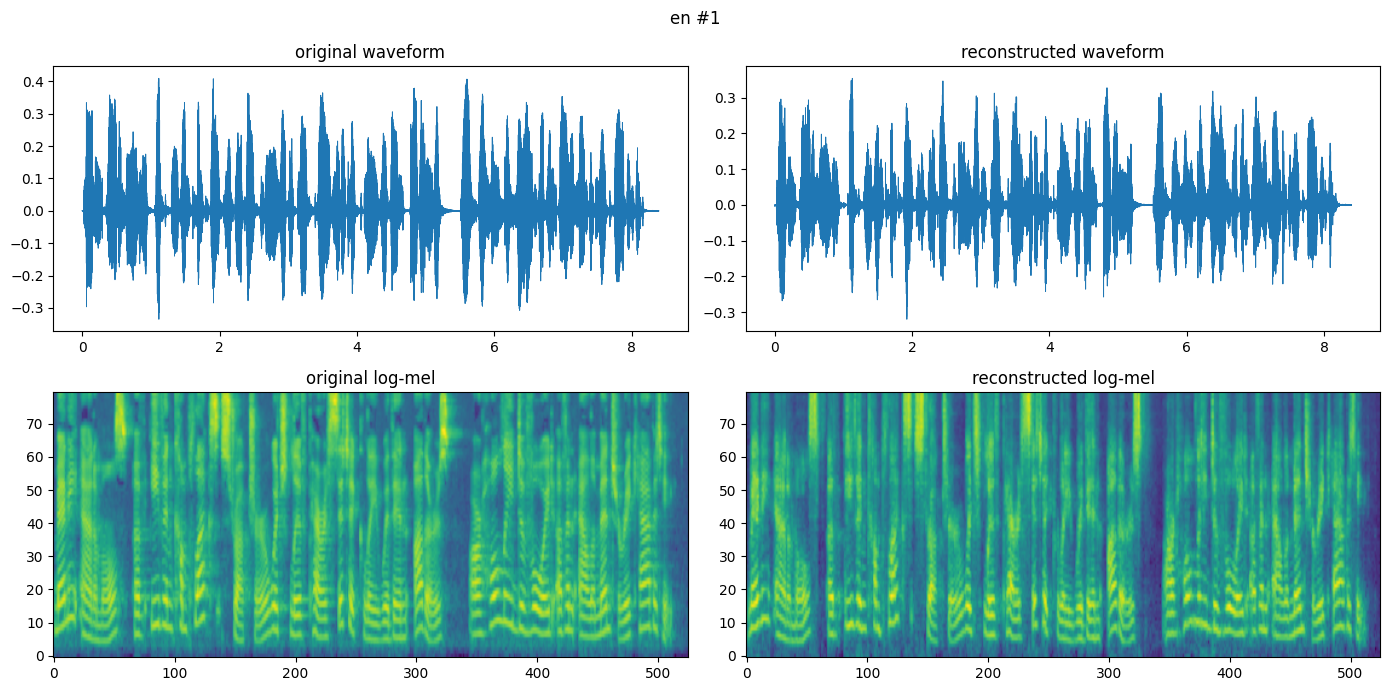

In [5]:
for i, url in enumerate(EXTERNAL_ENGLISH_URLS, 1):
    compare(download_audio(url), f"en #{i}")

## external (japanese)

### jap #1

original

reconstructed

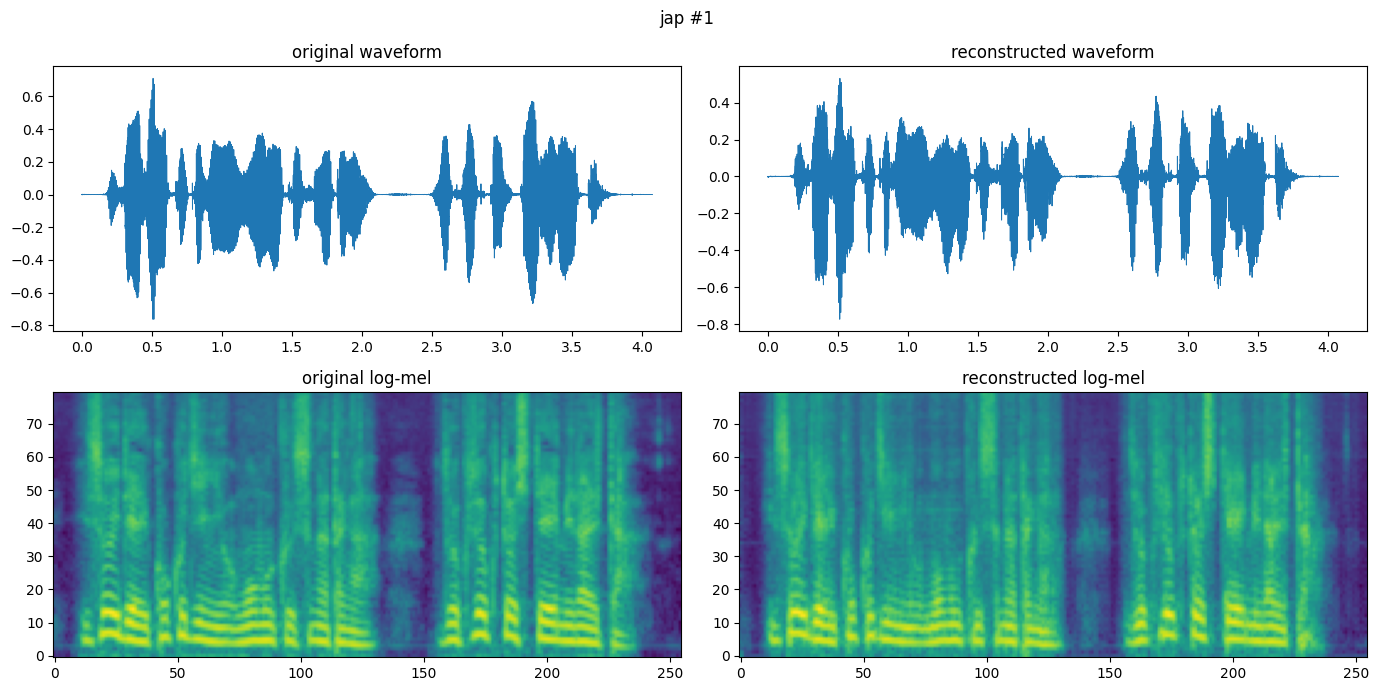

### jap #2

original

reconstructed

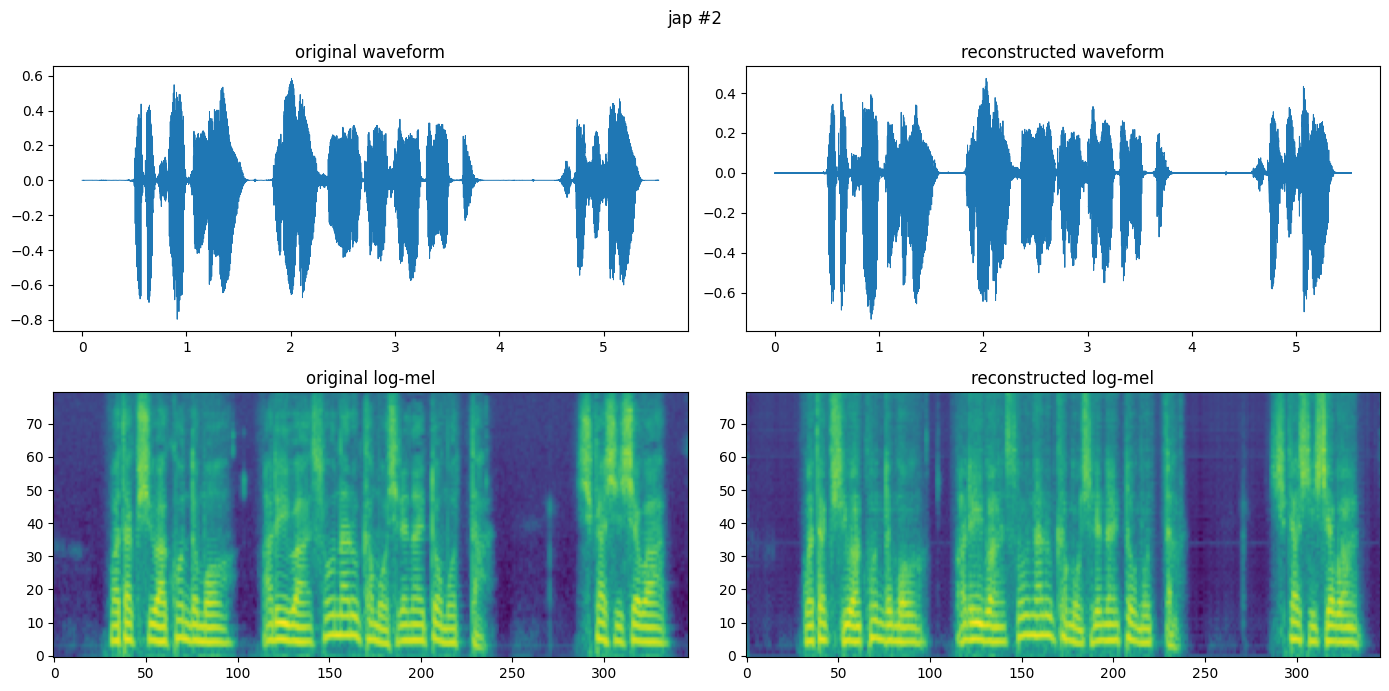

In [10]:
for i, url in enumerate(OTHER_URLS, 1):
    compare(download_audio(url), f"jap #{i}")